In [1]:
import os
import glob
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

import tensorflow as tf

TEST_SIZE=0.1
SEED=1
BATCH_SIZE=128

tf.random.set_seed(SEED)


In [2]:
labels_df = pd.read_csv('/kaggle/input/traffic-sign-dataset-classification/labels.csv')
print(labels_df.sample(10))

#Create a label map
label_map = dict(labels_df.values)

    ClassId                  Name
20       20  Go straight or right
4         4  Speed limit (50km/h)
35       35        Zebra Crossing
1         1  Speed limit (15km/h)
56       56              Unknown7
31       31                 Uturn
16       16                No Car
47       47        Train Crossing
48       48    Under Construction
25       25             keep Left


In [3]:
image_list = list(Path('/kaggle/input/traffic-sign-dataset-classification/traffic_Data/DATA').glob(r'**/*.png'))
labels = list(map(lambda path: os.path.split(os.path.split(path)[0])[1], image_list))

#Create dataframe with path of images and labels
image_series = pd.Series(image_list).astype(str)
labels_series = pd.Series(labels).astype(str)
frame = {'image':image_series, 'label':labels_series}
image_df = pd.DataFrame(frame)
image_df.info()
print(image_df.sample(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4170 entries, 0 to 4169
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   image   4170 non-null   object
 1   label   4170 non-null   object
dtypes: object(2)
memory usage: 65.3+ KB
                                                  image label
3553  /kaggle/input/traffic-sign-dataset-classificat...    11
2611  /kaggle/input/traffic-sign-dataset-classificat...     3
3196  /kaggle/input/traffic-sign-dataset-classificat...    14
2738  /kaggle/input/traffic-sign-dataset-classificat...     3
3234  /kaggle/input/traffic-sign-dataset-classificat...     4


<AxesSubplot:xlabel='label', ylabel='count images'>

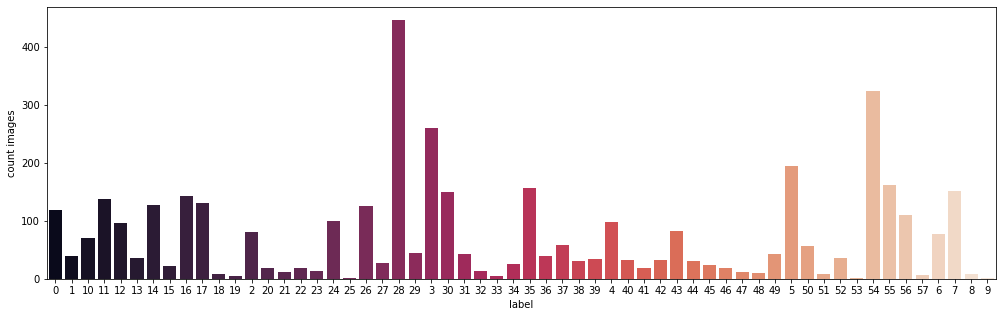

In [4]:
count_labels = image_df.groupby(['label']).size()
plt.figure(figsize=(17,5))
plt.ylabel('count images')
sns.barplot(x=count_labels.index, y=count_labels, palette="rocket")

Some labels contain very few image instances. If you apply random partitioning to training and validation, there is a chance that the training set will not reflect the entire general population. Let's split into training and validation only for the part where the number of image instances is higher than SPLIT_MINIMUM_COUNT

In [5]:
SPLIT_MINIMUM_COUNT = 10
def split_dataset(df, rate=SPLIT_MINIMUM_COUNT):
  """
  Allocate a  dataset that has at least SPLIT_MINIMUM_COUNT_IMAGES of images
  
  split_df: dataframe for train
  train1_df: dataframe for drop
  """

  count_labels = df.groupby(['label']).size()
  count_labels_df = count_labels.to_frame(name='count_images').reset_index()

  drop_label_list = list(
      count_labels_df['label'].\
      loc[count_labels_df['count_images']<SPLIT_MINIMUM_COUNT]
  )

  drop_df = df.copy()
  split_df = df.copy()

  for index, row in df.iterrows():
    if str(row.label) in drop_label_list:
      split_df = split_df.drop(index)
    else:
      drop_df = drop_df.drop(index)

  return split_df, drop_df

def custom_train_test_split(df):
    """
      Train test split where test_df has minimum 1 image in all labels
    in random split. This need to work model.fit and model.evaluate
    """
  
    labels = df.label.unique()
    test_df = pd.DataFrame()

    for label in labels:
      label_samples = df.loc[df.label==label]
      test_df = test_df.append(label_samples.sample(len(label_samples)//10+1,
                               random_state=SEED))
    
    train_df = df.drop(list(test_df.index), axis=0)
    test_df = test_df.sample(frac=1, random_state=SEED)
    train_df = train_df.sample(frac=1, random_state=SEED)

    return train_df, test_df


In [6]:
split_df, _ = split_dataset(image_df)
train_df, test_df = custom_train_test_split(split_df)
train, val = custom_train_test_split(train_df)


In [7]:
train_labels = train_df.groupby(['label']).size()
NUM_CLASSES = len(train_labels)

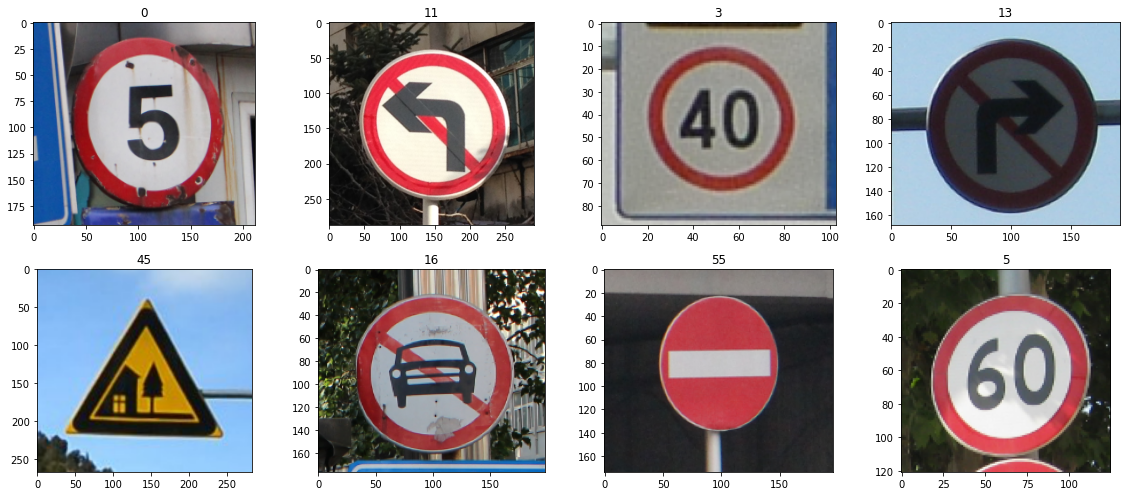

In [8]:
#plot images
fig, axes = plt.subplots(2,4, figsize=(16, 7))
for idx, ax in enumerate(axes.flat):
    ax.imshow(plt.imread(train_df.image.iloc[idx]))
    ax.set_title(train_df.label.iloc[idx])
plt.tight_layout()
plt.show()

Parth 2. Train model

In [9]:
train_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,
    rotation_range = 10,
    width_shift_range=0.2,
    height_shift_range=0.2,
    fill_mode='constant',
    shear_range=0.1,
    zoom_range=0.2,
)

test_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,
)

In [10]:
train_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='image',
    y_col='label',
    color_mode='rgb',
    class_mode='categorical',
    target_size=(128, 128),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

val_images = test_generator.flow_from_dataframe(
    dataframe=val,
    x_col='image',
    y_col='label',
    color_mode='rgb',
    class_mode='categorical',
    target_size=(128, 128),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)


test_images = test_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col='image',
    y_col='label',
    color_mode='rgb',
    class_mode='categorical',
    target_size=(128, 128),
    batch_size=BATCH_SIZE,
)


Found 3683 validated image filenames belonging to 49 classes.
Found 396 validated image filenames belonging to 49 classes.
Found 443 validated image filenames belonging to 49 classes.


In [11]:
#create model
def create_model(input_shape=(128,128,3)):
  """
  load EfficientNet without last layer and 
  add Dense and ouput Dense with NUM_CLASSES units

  """
  inputs = tf.keras.layers.Input(input_shape)

  base_model = tf.keras.applications.EfficientNetB0(
      include_top=False,
      weights='imagenet',
      pooling='avg'
  )
  base_model.trainable = False
  
  x = base_model(inputs)
  x = tf.keras.layers.BatchNormalization()(x)
  x = tf.keras.layers.Dense(512, activation='relu')(x)
  #x = tf.keras.layers.Dropout(0.2)(x)
  #x = tf.keras.layers.Dense(256, activation='relu')(x)
  outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)

  return tf.keras.models.Model(inputs, outputs)

In [12]:
model = create_model()

16719872/16705208 [==============================] - 0s 0us/step


In [13]:
model.compile(
    optimizer='Adam',
    loss='categorical_crossentropy',
    metrics=['acc'],
)

In [14]:
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)

history = model.fit(
    train_images,
    epochs=40,
    validation_data=val_images,
    callbacks=[callback]
)

Epoch 1/40
29/29 [==============================] - 40s 1s/step - loss: 1.2266 - acc: 0.6831 - val_loss: 1.2729 - val_acc: 0.7879
Epoch 2/40
29/29 [==============================] - 20s 686ms/step - loss: 0.3038 - acc: 0.9099 - val_loss: 0.8656 - val_acc: 0.8838
Epoch 3/40
29/29 [==============================] - 20s 693ms/step - loss: 0.1854 - acc: 0.9438 - val_loss: 0.6150 - val_acc: 0.9192
Epoch 4/40
29/29 [==============================] - 20s 684ms/step - loss: 0.1453 - acc: 0.9549 - val_loss: 0.4339 - val_acc: 0.9318
Epoch 5/40
29/29 [==============================] - 20s 692ms/step - loss: 0.1005 - acc: 0.9696 - val_loss: 0.3317 - val_acc: 0.9444
Epoch 6/40
29/29 [==============================] - 20s 703ms/step - loss: 0.0848 - acc: 0.9737 - val_loss: 0.2384 - val_acc: 0.9621
Epoch 7/40
29/29 [==============================] - 21s 718ms/step - loss: 0.0756 - acc: 0.9788 - val_loss: 0.2016 - val_acc: 0.9495
Epoch 8/40
29/29 [==============================] - 21s 706ms/step - los

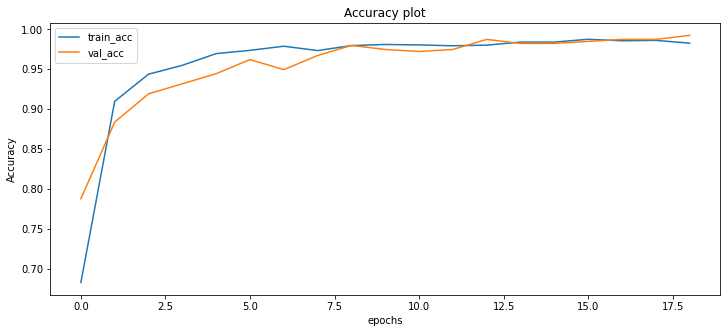

In [15]:
plt.figure(figsize=(12,5))
plt.plot(history.history['acc'], label='train_acc')
plt.plot(history.history['val_acc'], label='val_acc')
plt.title('Accuracy plot')
plt.xlabel('epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [16]:
score, accuracy = model.evaluate(test_images)
print(f'Test score: {round(score,4)}, Test accuracy: {round(accuracy,4)}')

4/4 [==============================] - 2s 564ms/step - loss: 0.0615 - acc: 0.9819
Test score: 0.0615, Test accuracy: 0.9819


In [17]:
model.save("/kaggle/working/traffic_sign_model")


/opt/conda/lib/python3.7/site-packages/keras/utils/generic_utils.py:497: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  category=CustomMaskWarning)


In [18]:
# Also save in .keras format (backup)
model.save("/kaggle/working/traffic_sign_model.keras")

prediction and speak starts here

In [19]:
model.save("/kaggle/working/model/traffic_sign_model", save_format='tf')

/opt/conda/lib/python3.7/site-packages/keras/utils/generic_utils.py:497: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  category=CustomMaskWarning)


In [20]:
from tensorflow.keras.preprocessing import image
import numpy as np

def predict_single_image(img_path, model, label_map, target_size=(128, 128)):
    # Step 1: Load and preprocess the image
    img = image.load_img(img_path, target_size=target_size)  # Load image
    img_array = image.img_to_array(img)  # Convert to numpy array
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)  # Preprocess the image
    
    # Step 2: Make a prediction
    predictions = model.predict(img_array)
    
    # Step 3: Get the predicted class index and map it to the class label
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    predicted_class_label = label_map.get(predicted_class_index)
    
    return predicted_class_label

# Test the function
img_path = '/kaggle/input/traffic-sign-dataset-classification/traffic_Data/TEST/000_0001_j.png'  # Replace with the actual path to the image you want to test
predicted_class = predict_single_image(img_path, model, label_map)
print(f'The image belongs to class: {predicted_class}')


The image belongs to class: Bicycles crossing


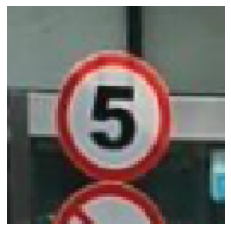

The image belongs to class: Speed limit (5km/h)


In [21]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def predict_and_show_image(img_path, model, label_map, target_size=(128, 128)):
    # Step 1: Load and display the image
    img = image.load_img(img_path, target_size=target_size)
    plt.imshow(img)
    plt.axis('off')  # Hide axes
    plt.show()
    
    # Step 2: Preprocess the image for the model
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)
    
    # Step 3: Make prediction
    predictions = model.predict(img_array)
    
    # Step 4: Map predicted index to class label
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    predicted_class_label = label_map.get(predicted_class_index)
    
    return predicted_class_label

# Example usage
img_path = '/kaggle/input/traffic-sign-dataset-classification/traffic_Data/TEST/000_0007_j.png'
predicted_class = predict_and_show_image(img_path, model, label_map)
print(f'The image belongs to class: {predicted_class}')
